In [9]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [10]:
df = pd.read_csv("../dataset.csv")
df.head()

,ID,No_Pation,Gender,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI,CLASS
0,502,17975,F,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
1,735,34221,M,26,4.5,62,4.9,3.7,1.4,1.1,2.1,0.6,23.0,N
2,420,47975,F,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
3,680,87656,F,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
4,504,34223,M,33,7.1,46,4.9,4.9,1.0,0.8,2.0,0.4,21.0,N


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   ID         1000 non-null   int64  
 1   No_Pation  1000 non-null   int64  
 2   Gender     1000 non-null   object 
 3   AGE        1000 non-null   int64  
 4   Urea       1000 non-null   float64
 5   Cr         1000 non-null   int64  
 6   HbA1c      1000 non-null   float64
 7   Chol       1000 non-null   float64
 8   TG         1000 non-null   float64
 9   HDL        1000 non-null   float64
 10  LDL        1000 non-null   float64
 11  VLDL       1000 non-null   float64
 12  BMI        1000 non-null   float64
 13  CLASS      1000 non-null   object 
dtypes: float64(8), int64(4), object(2)
memory usage: 109.5+ KB


In [12]:
df['CLASS'] = df['CLASS'].str.strip().str.upper()
df['Gender'] = df['Gender'].str.strip().str.upper()

In [20]:
print(f"Duplicate rows found: {df.duplicated().sum()}")

print("\nNumerical Summary:")
display(df.describe().round(2))

Duplicate rows found: 0

Numerical Summary:


,ID,No_Pation,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI
count,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00
mean,340.50,270551.41,53.53,5.12,68.94,8.28,4.86,2.35,1.20,2.61,1.85,29.58
std,240.40,3380757.82,8.80,2.94,59.98,2.53,1.30,1.40,0.66,1.12,3.66,4.96
min,1.00,123.00,20.00,0.50,6.00,0.90,0.00,0.30,0.20,0.30,0.10,19.00
25%,125.75,24063.75,51.00,3.70,48.00,6.50,4.00,1.50,0.90,1.80,0.70,26.00
50%,300.50,34395.50,55.00,4.60,60.00,8.00,4.80,2.00,1.10,2.50,0.90,30.00
75%,550.25,45384.25,59.00,5.70,73.00,10.20,5.60,2.90,1.30,3.30,1.50,33.00
max,800.00,75435657.00,79.00,38.90,800.00,16.00,10.30,13.80,9.90,9.90,35.00,47.75


In [14]:
print(f"null found: {df.isna().sum()}")

null found: ID           0
No_Pation    0
Gender       0
AGE          0
Urea         0
Cr           0
HbA1c        0
Chol         0
TG           0
HDL          0
LDL          0
VLDL         0
BMI          0
CLASS        0
dtype: int64


In [15]:
print("\n── CLASS distribution ──")
print(df['CLASS'].value_counts())
 
print("\n── Gender distribution ──")
print(df['Gender'].value_counts())


── CLASS distribution ──
CLASS
Y    844
N    103
P     53
Name: count, dtype: int64

── Gender distribution ──
Gender
M    565
F    435
Name: count, dtype: int64


C:\Users\start\AppData\Local\Temp\ipykernel_20760\1325371272.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='CLASS', order=order, palette='Set2', ax=axes[0])
C:\Users\start\AppData\Local\Temp\ipykernel_20760\1325371272.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Gender', palette='Set2', ax=axes[1])


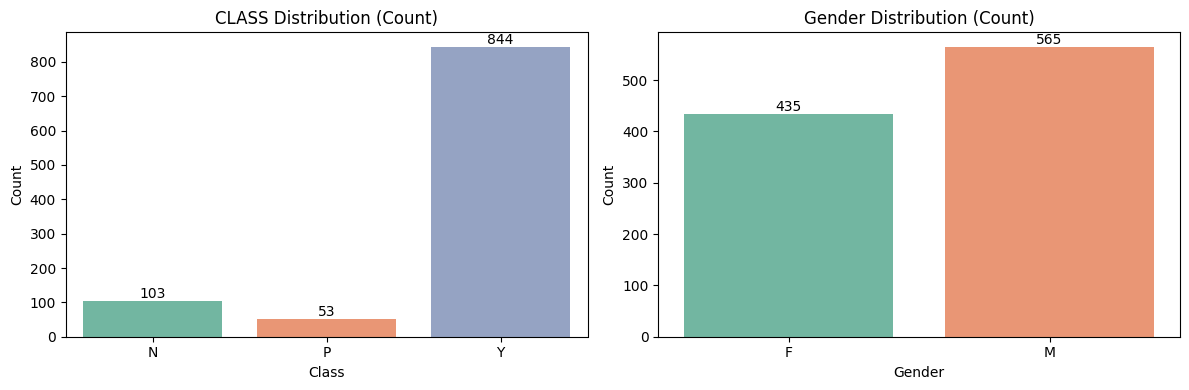

In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# First plot: CLASS distribution (same as before)
order = ['N', 'P', 'Y']
sns.countplot(data=df, x='CLASS', order=order, palette='Set2', ax=axes[0])
axes[0].set_title('CLASS Distribution (Count)')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Count')

for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}',
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=10)

# Second plot: Gender distribution 
sns.countplot(data=df, x='Gender', palette='Set2', ax=axes[1])
axes[1].set_title('Gender Distribution (Count)')
axes[1].set_xlabel('Gender')
axes[1].set_ylabel('Count')

for p in axes[1].patches:
    axes[1].annotate(f'{int(p.get_height())}',
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('01_class_and_gender_distribution.png', dpi=150)
plt.show()

In [19]:
num_cols = ['AGE', 'Urea', 'Cr', 'HbA1c', 'Chol', 'TG', 'HDL', 'LDL', 'VLDL', 'BMI']
print('── Mean values by CLASS ──')
display(df.groupby('CLASS')[num_cols].mean().round(2))
 
print('\n── Median values by CLASS ──')
display(df.groupby('CLASS')[num_cols].median().round(2))
 
print('\n── Std deviation by CLASS ──')
display(df.groupby('CLASS')[num_cols].std().round(2))
 
print('\n── Min values by CLASS ──')
display(df.groupby('CLASS')[num_cols].min().round(2))
 
print('\n── Max values by CLASS ──')
display(df.groupby('CLASS')[num_cols].max().round(2))

── Mean values by CLASS ──


,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI
CLASS,,,,,,,,,,
N,44.23,4.68,62.80,4.56,4.27,1.63,1.23,2.63,0.94,22.37
P,43.28,4.51,66.08,6.00,4.58,2.13,1.13,2.49,0.98,23.93
Y,55.31,5.22,69.87,8.88,4.95,2.45,1.21,2.62,2.02,30.81



── Median values by CLASS ──


,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI
CLASS,,,,,,,,,,
N,44.0,4.4,55.0,4.9,4.2,1.3,1.1,2.6,0.7,22.0
P,48.0,4.4,59.0,6.0,4.7,1.8,1.0,2.5,0.8,24.0
Y,55.0,4.6,60.5,8.8,4.9,2.1,1.1,2.5,1.0,30.0



── Std deviation by CLASS ──


,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI
CLASS,,,,,,,,,,
N,9.42,2.52,30.02,0.92,1.28,1.03,0.51,0.98,1.48,1.42
P,7.76,2.02,41.57,0.19,1.04,1.06,0.38,0.87,0.50,2.71
Y,7.55,3.02,63.58,2.26,1.30,1.43,0.69,1.14,3.93,4.32



── Min values by CLASS ──


,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI
CLASS,,,,,,,,,,
N,25,2.0,6,0.9,0.0,0.6,0.5,0.3,0.2,19.0
P,30,2.1,37,5.7,2.0,0.8,0.6,0.8,0.4,19.0
Y,20,0.5,20,2.0,0.6,0.3,0.2,0.5,0.1,19.0



── Max values by CLASS ──


,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI
CLASS,,,,,,,,,,
N,77,22.0,203,5.6,9.5,5.9,4.0,4.9,14.5,24.60
P,55,17.1,344,6.4,6.5,5.3,2.5,3.9,2.4,32.00
Y,79,38.9,800,16.0,10.3,13.8,9.9,9.9,35.0,47.75


In [21]:
print('\n── Full describe — Non-Diabetic (N) ──')
display(df[df['CLASS'] == 'N'][num_cols].describe().round(2))
 
print('\n── Full describe — Pre-Diabetic (P) ──')
display(df[df['CLASS'] == 'P'][num_cols].describe().round(2))
 
print('\n── Full describe — Diabetic (Y) ──')
display(df[df['CLASS'] == 'Y'][num_cols].describe().round(2))


── Full describe — Non-Diabetic (N) ──


,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI
count,103.00,103.00,103.00,103.00,103.00,103.00,103.00,103.00,103.00,103.00
mean,44.23,4.68,62.80,4.56,4.27,1.63,1.23,2.63,0.94,22.37
std,9.42,2.52,30.02,0.92,1.28,1.03,0.51,0.98,1.48,1.42
min,25.00,2.00,6.00,0.90,0.00,0.60,0.50,0.30,0.20,19.00
25%,38.50,3.30,45.50,4.10,3.65,1.00,0.90,1.90,0.55,21.00
50%,44.00,4.40,55.00,4.90,4.20,1.30,1.10,2.60,0.70,22.00
75%,50.00,5.45,71.50,5.10,4.80,1.80,1.30,3.25,1.00,24.00
max,77.00,22.00,203.00,5.60,9.50,5.90,4.00,4.90,14.50,24.60



── Full describe — Pre-Diabetic (P) ──


,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI
count,53.00,53.00,53.00,53.00,53.00,53.00,53.00,53.00,53.00,53.00
mean,43.28,4.51,66.08,6.00,4.58,2.13,1.13,2.49,0.98,23.93
std,7.76,2.02,41.57,0.19,1.04,1.06,0.38,0.87,0.50,2.71
min,30.00,2.10,37.00,5.70,2.00,0.80,0.60,0.80,0.40,19.00
25%,35.00,3.40,53.00,5.90,4.00,1.30,0.80,1.90,0.60,23.00
50%,48.00,4.40,59.00,6.00,4.70,1.80,1.00,2.50,0.80,24.00
75%,50.00,5.00,64.00,6.10,5.30,2.40,1.40,3.20,1.30,25.00
max,55.00,17.10,344.00,6.40,6.50,5.30,2.50,3.90,2.40,32.00



── Full describe — Diabetic (Y) ──


,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI
count,844.00,844.00,844.00,844.00,844.00,844.00,844.00,844.00,844.00,844.00
mean,55.31,5.22,69.87,8.88,4.95,2.45,1.21,2.62,2.02,30.81
std,7.55,3.02,63.58,2.26,1.30,1.43,0.69,1.14,3.93,4.32
min,20.00,0.50,20.00,2.00,0.60,0.30,0.20,0.50,0.10,19.00
25%,53.00,3.70,48.00,7.20,4.10,1.50,0.90,1.80,0.70,28.00
50%,55.00,4.60,60.50,8.80,4.90,2.10,1.10,2.50,1.00,30.00
75%,60.00,5.80,73.00,10.40,5.70,3.00,1.30,3.30,1.50,33.00
max,79.00,38.90,800.00,16.00,10.30,13.80,9.90,9.90,35.00,47.75


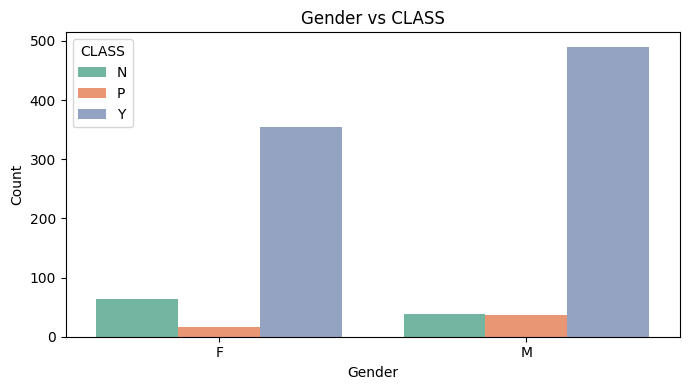

In [17]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.countplot(data=df, x='Gender', hue='CLASS', hue_order=order,
              palette='Set2', ax=ax)
ax.set_title('Gender vs CLASS')
ax.set_xlabel('Gender')
ax.set_ylabel('Count')
plt.tight_layout()
plt.savefig('02_gender_vs_class.png', dpi=150)
plt.show()

In [24]:
from scipy import stats
print("which features are important in distinguishing the classes") 
print('\n── One-Way ANOVA: feature vs CLASS ── ')
print(f"{'Feature':<10}  {'F-stat':>10}  {'p-value':>12}  {'Significant?':>13}")
print('-' * 52)
for col in num_cols:
    groups = [grp[col].dropna().values for _, grp in df.groupby('CLASS')]
    f_stat, p_val = stats.f_oneway(*groups)
    sig = '✅ Yes' if p_val < 0.05 else '❌ No'
    print(f"{col:<10}  {f_stat:>10.2f}  {p_val:>12.4e}  {sig:>13}")

which features are important in distinguishing the classes

── One-Way ANOVA: feature vs CLASS ── 
Feature         F-stat       p-value   Significant?
----------------------------------------------------
AGE             141.79    6.4055e-55          ✅ Yes
Urea              2.77    6.3292e-02           ❌ No
Cr                0.70    4.9563e-01           ❌ No
HbA1c           226.15    1.0314e-81          ✅ Yes
Chol             14.38    6.9551e-07          ✅ Yes
TG               17.23    4.3869e-08          ✅ Yes
HDL               0.43    6.5244e-01           ❌ No
LDL               0.31    7.3486e-01           ❌ No
VLDL              5.60    3.8102e-03          ✅ Yes
BMI             254.61    4.7143e-90          ✅ Yes


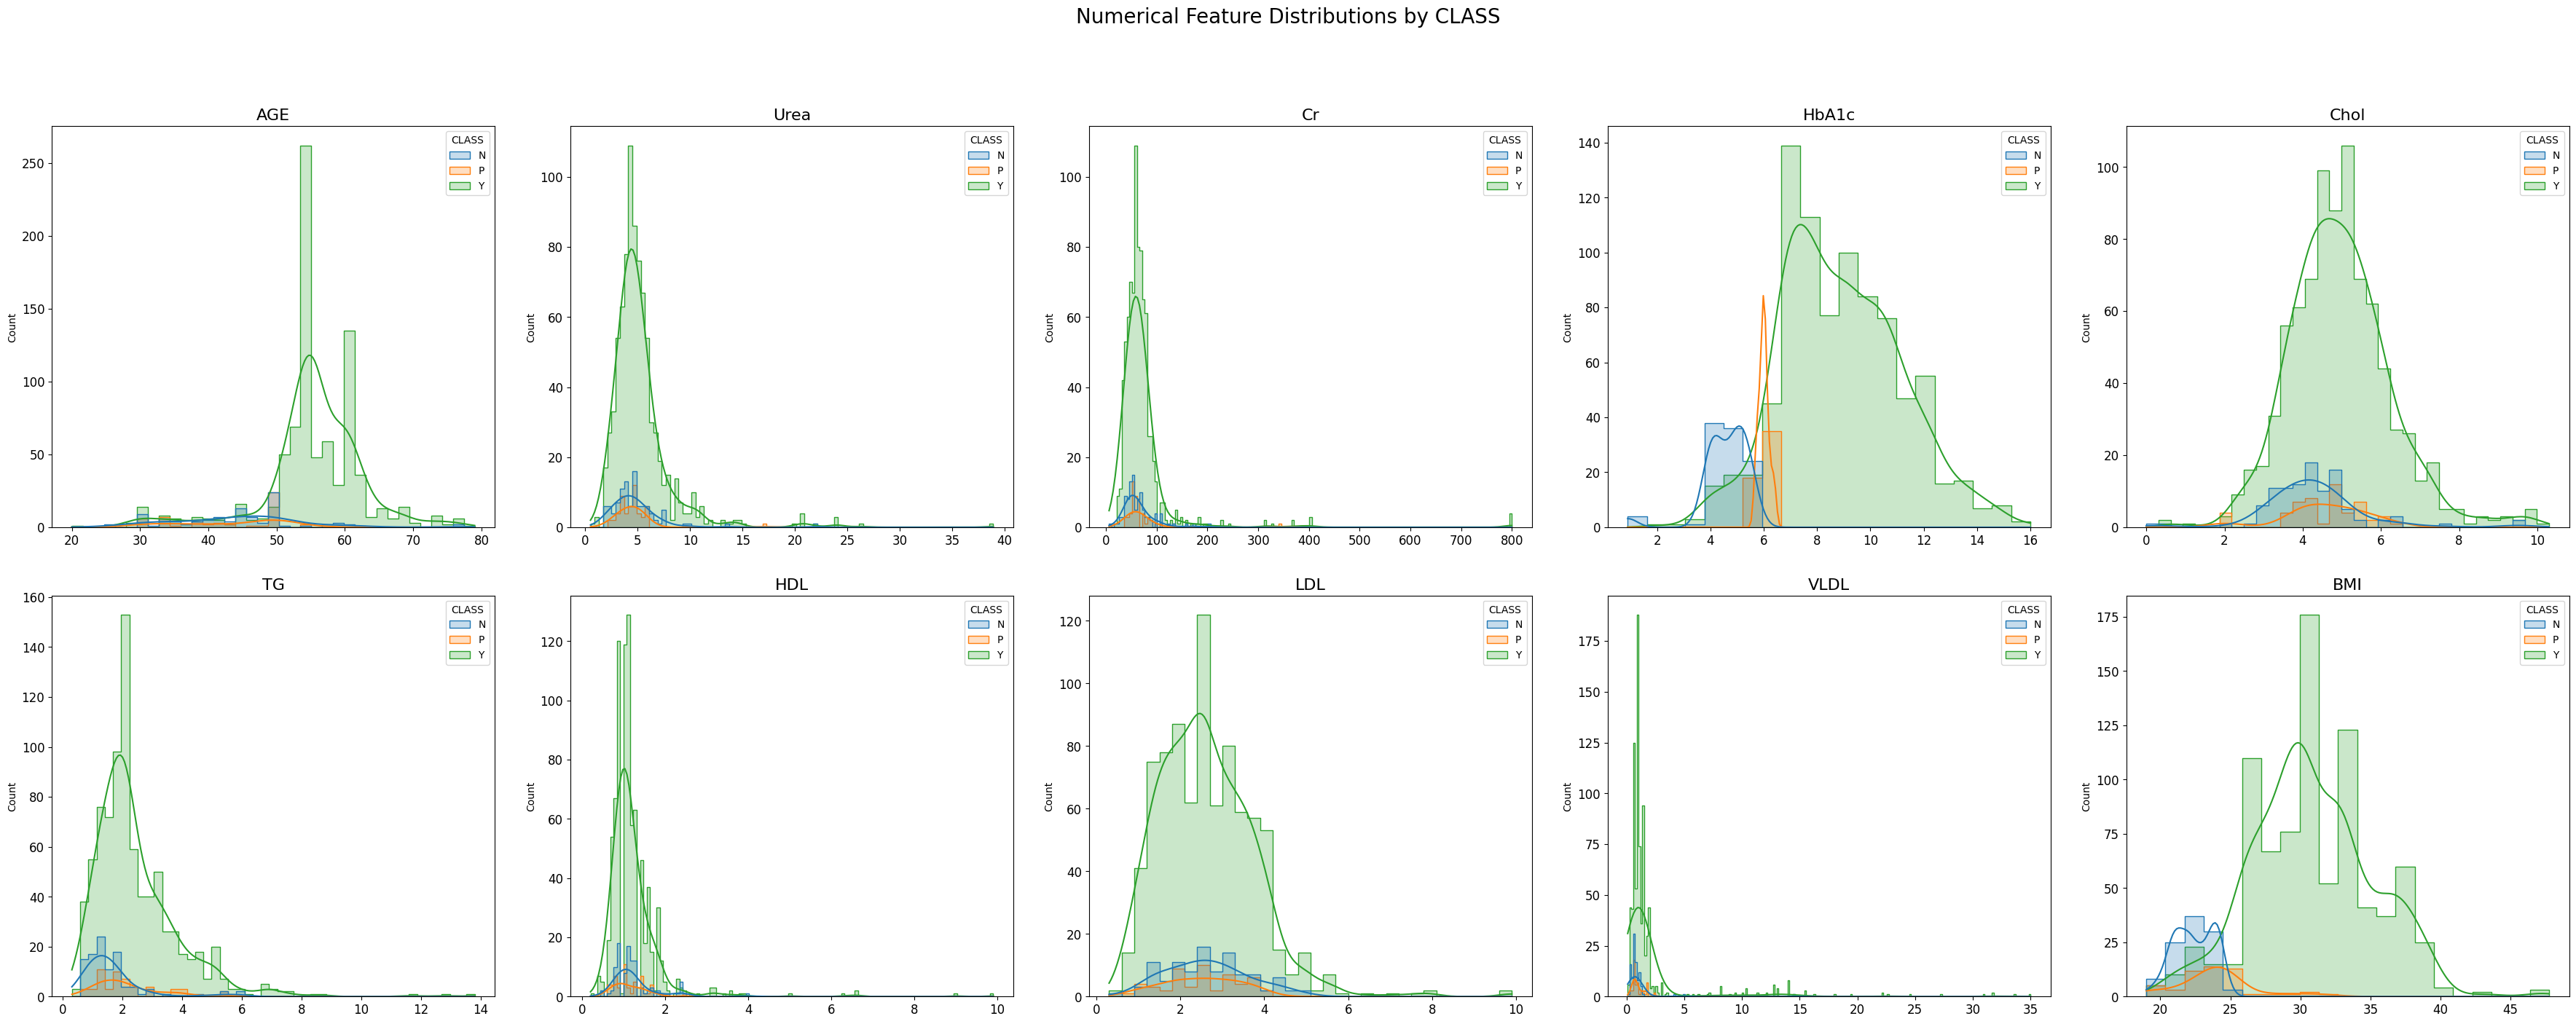

In [27]:
fig, axes = plt.subplots(2, 5, figsize=(36, 14))  # much wider and taller
axes = axes.flatten()

# Use a more distinct color palette
custom_palette = ['#1f77b4', '#ff7f0e', '#2ca02c']  # blue, orange, green

for i, col in enumerate(num_cols):
    sns.histplot(
        data=df,
        x=col,
        hue='CLASS',
        hue_order=order,
        kde=True,
        palette=custom_palette,
        ax=axes[i],
        element='step'
    )
    axes[i].set_title(col, fontsize=16)
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='both', labelsize=12)

plt.suptitle('Numerical Feature Distributions by CLASS', fontsize=20, y=1.02)
plt.tight_layout(pad=3.0)
plt.show()

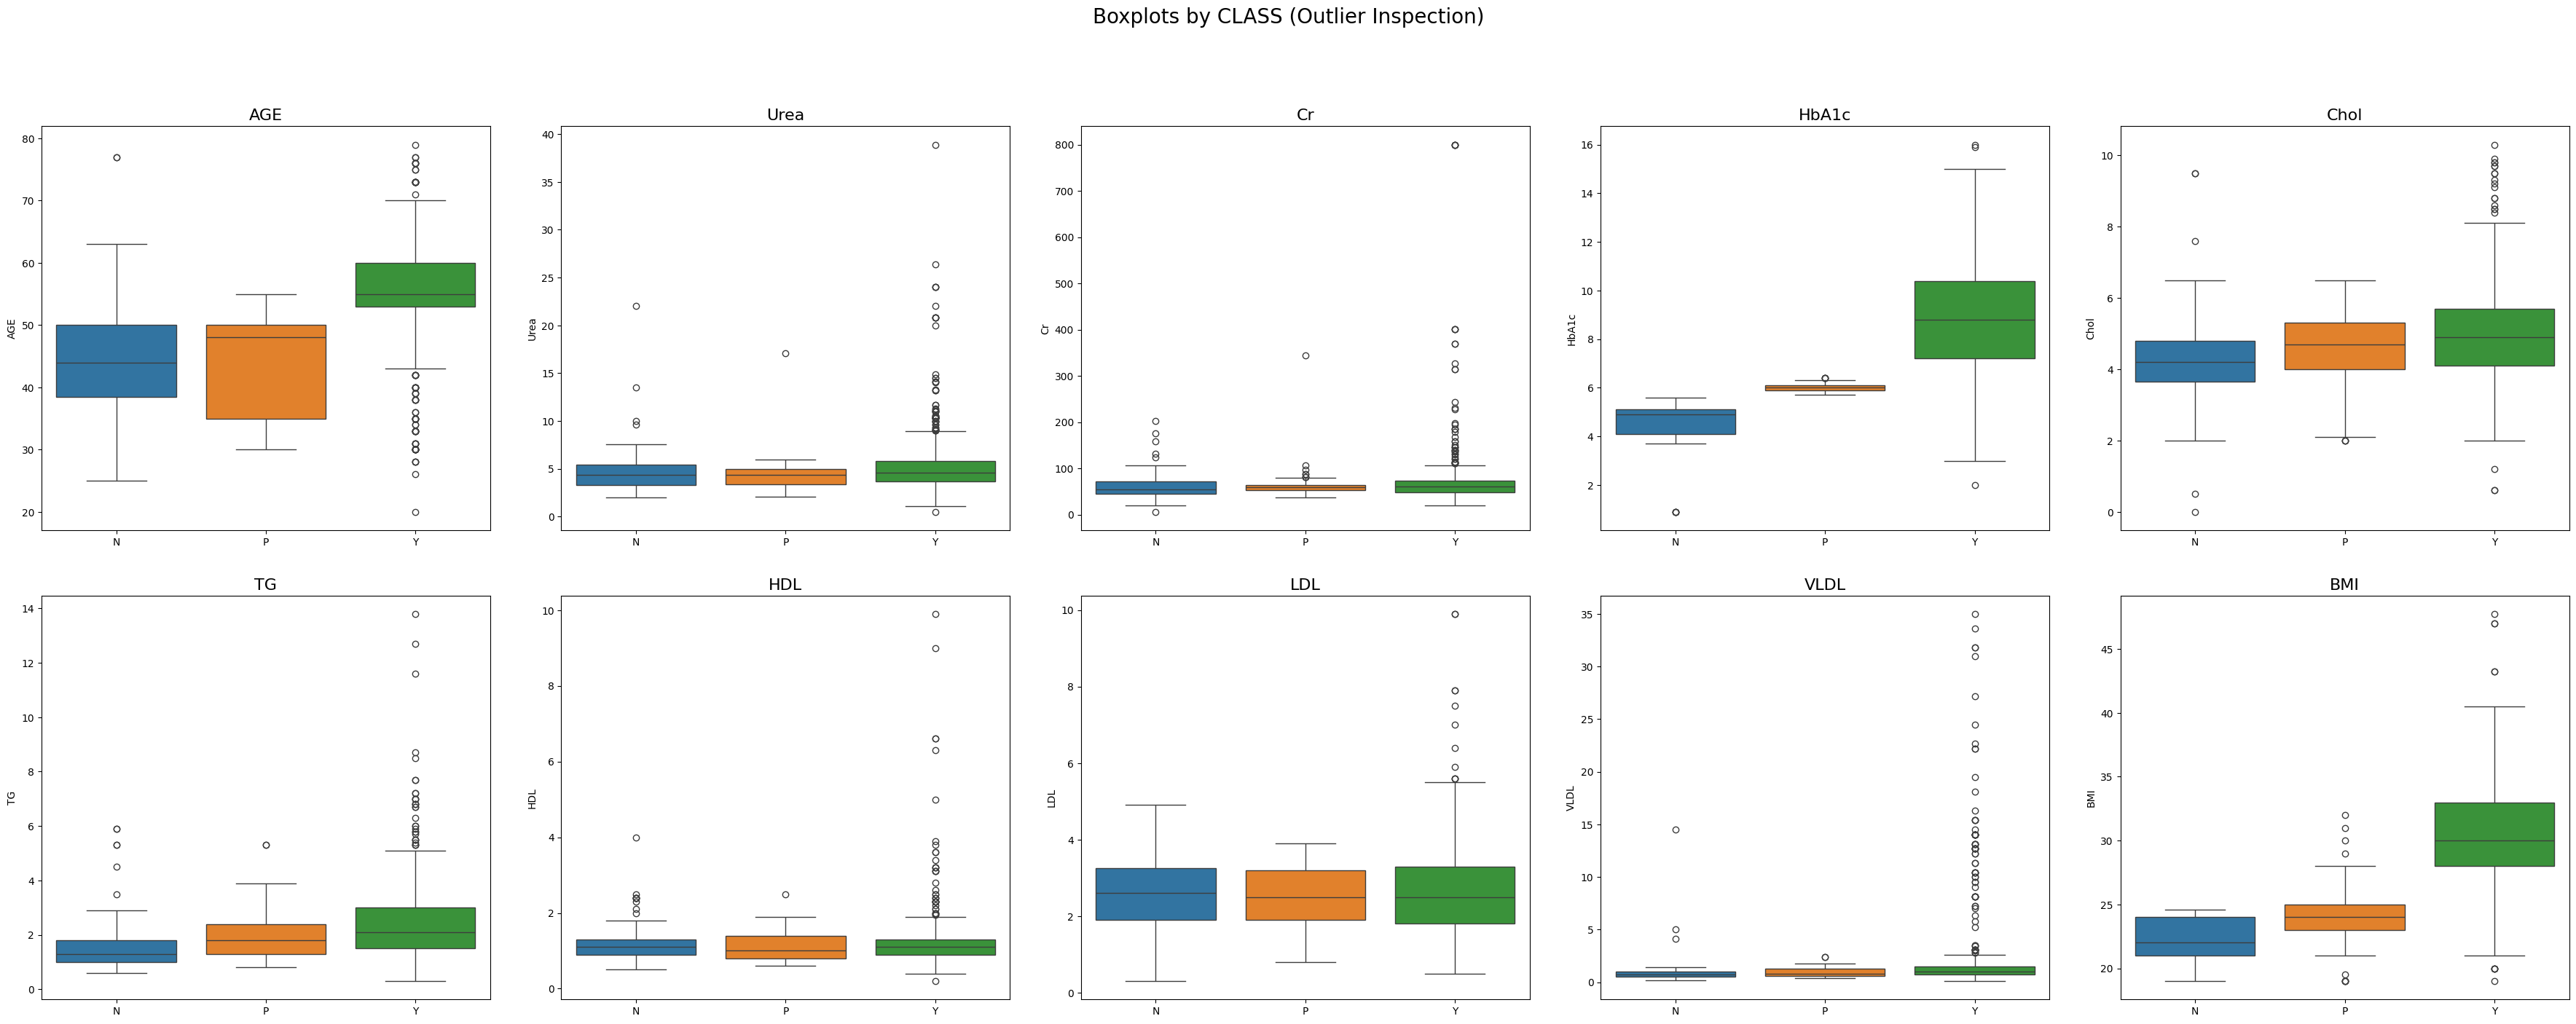

In [30]:
custom_palette = {'N': '#1f77b4', 'P': '#ff7f0e', 'Y': '#2ca02c'}

fig, axes = plt.subplots(2, 5, figsize=(36, 14))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(
        data=df,
        x='CLASS',
        y=col,
        order=order,
        hue='CLASS',
        palette=custom_palette,
        ax=axes[i],
        dodge=False,
        showfliers=True
    )
    axes[i].set_title(col, fontsize=16)
    axes[i].set_xlabel('')
    
    # remove legend if it exists
    if axes[i].legend_:
        axes[i].legend_.remove()

plt.suptitle('Boxplots by CLASS (Outlier Inspection)', fontsize=20, y=1.02)
plt.tight_layout(pad=3.0)
plt.show()

In [31]:
print("\n── Outlier count per column (IQR method) ──")
for col in num_cols:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    n_out = ((df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)).sum()
    print(f"  {col:<8}: {n_out} outliers")
 


── Outlier count per column (IQR method) ──
  AGE     : 98 outliers
  Urea    : 65 outliers
  Cr      : 52 outliers
  HbA1c   : 6 outliers
  Chol    : 27 outliers
  TG      : 55 outliers
  HDL     : 50 outliers
  LDL     : 11 outliers
  VLDL    : 74 outliers
  BMI     : 3 outliers


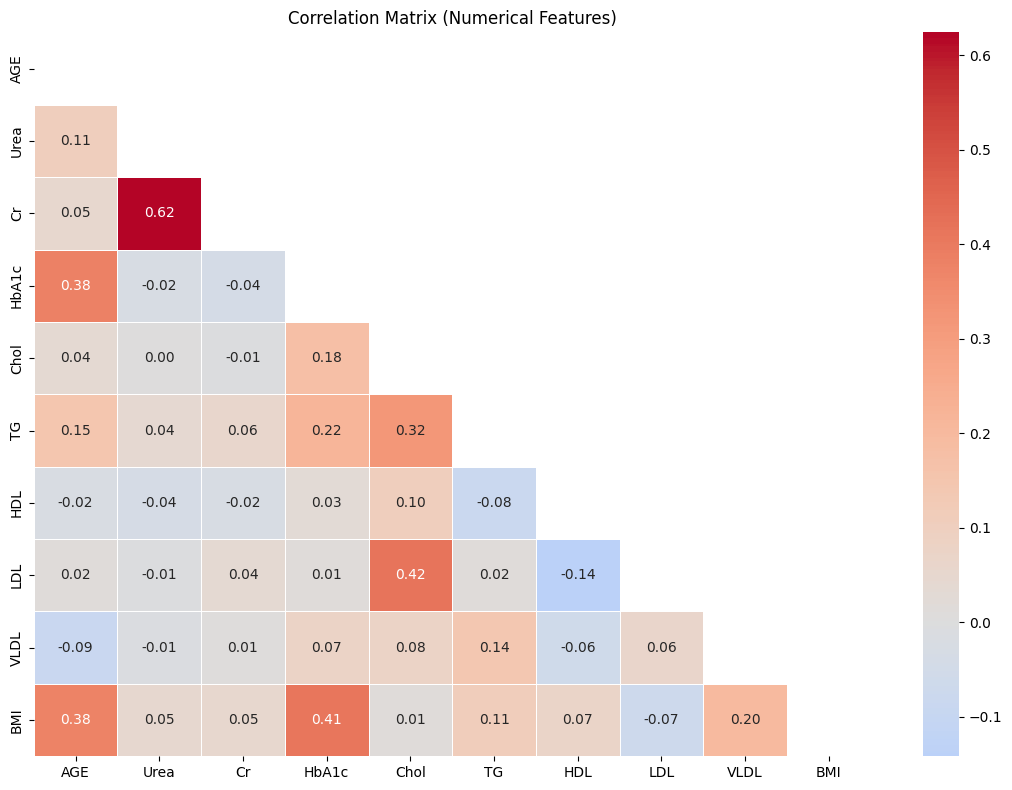

In [32]:
fig, ax = plt.subplots(figsize=(11, 8))
corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax)
ax.set_title('Correlation Matrix (Numerical Features)')
plt.tight_layout()
plt.savefig('05_correlation_heatmap.png', dpi=150)
plt.show()

In [35]:
# Compute the lower triangle of the correlation matrix
lower_triangle = corr.mask(np.triu(np.ones(corr.shape, dtype=bool)))

# Convert to long format (pairs)
corr_long = lower_triangle.stack().reset_index()
corr_long.columns = ['Feature 1', 'Feature 2', 'Correlation']

# Add absolute correlation for sorting
corr_long['AbsCorr'] = corr_long['Correlation'].abs()

# Get top 10 strongest correlations
top_corrs = corr_long.sort_values('AbsCorr', ascending=False).iloc[:10].drop('AbsCorr', axis=1)

print("Top 10 strongest feature correlations:")
print(top_corrs.to_string(index=False))

Top 10 strongest feature correlations:
Feature 1 Feature 2  Correlation
       Cr      Urea     0.624134
      LDL      Chol     0.416665
      BMI     HbA1c     0.413350
    HbA1c       AGE     0.379136
      BMI       AGE     0.375956
       TG      Chol     0.321789
       TG     HbA1c     0.218556
      BMI      VLDL     0.198133
     Chol     HbA1c     0.177489
       TG       AGE     0.148204


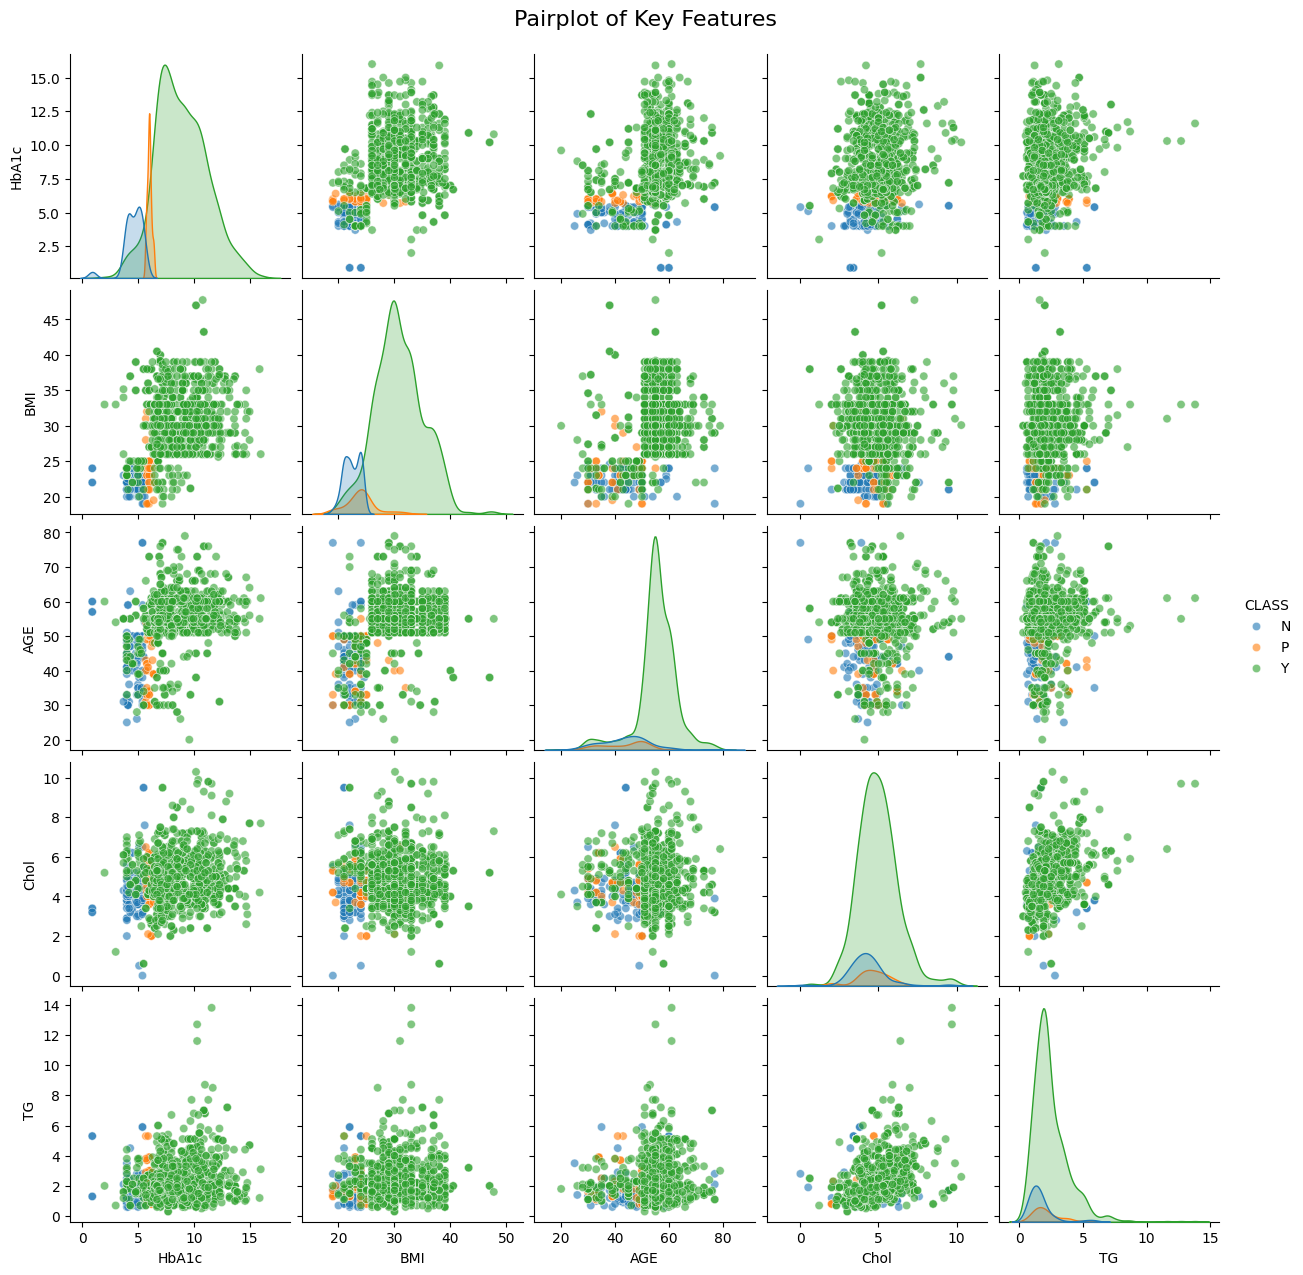

In [36]:
# Create a subset of key features
subset = df[['HbA1c', 'BMI', 'AGE', 'Chol', 'TG', 'CLASS']].copy()

# Stronger colors for classes
strong_palette = {'N': '#1f77b4',  # strong blue
                  'P': '#ff7f0e',  # strong orange
                  'Y': '#2ca02c'}  # strong green

# Pairplot
pp = sns.pairplot(
    subset,
    hue='CLASS',
    hue_order=order,
    palette=strong_palette,
    diag_kind='kde',
    plot_kws={'alpha': 0.6}  # slightly more opaque
)

# Add title
pp.fig.suptitle('Pairplot of Key Features', y=1.02, fontsize=16)

# Save and show
plt.savefig('07_pairplot_strong_colors.png', dpi=150, bbox_inches='tight')
plt.show()
 

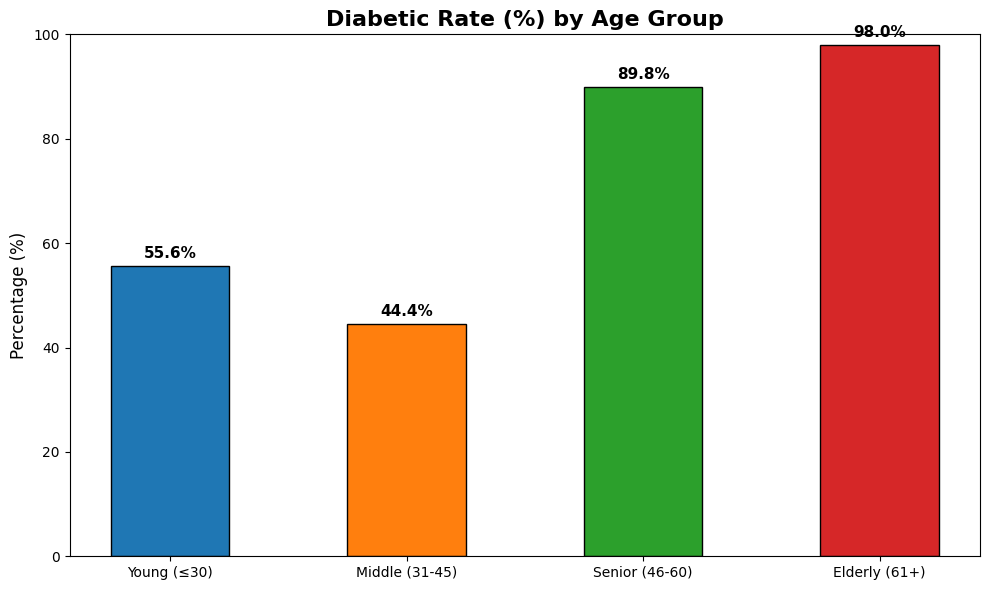


Diabetic rate by age group (%):
Age_Group
Young (≤30)       55.6
Middle (31-45)    44.4
Senior (46-60)    89.8
Elderly (61+)     98.0


In [42]:
# Create age groups
df['Age_Group'] = pd.cut(
    df['AGE'],
    bins=[0, 30, 45, 60, 100],
    labels=['Young (≤30)', 'Middle (31-45)', 'Senior (46-60)', 'Elderly (61+)']
)

# Group by age and class, use observed=True to avoid FutureWarning
age_class = df.groupby(['Age_Group', 'CLASS'], observed=True).size().unstack(fill_value=0)

# Convert to percentages
age_pct = age_class.div(age_class.sum(axis=1), axis=0) * 100

# Plot
fig, ax = plt.subplots(figsize=(10, 6))

# Stronger contrasting colors
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']  # blue, orange, green, red

diabetic_rates = age_pct['Y']
bars = ax.bar(age_pct.index, diabetic_rates,
              color=colors,
              width=0.5, edgecolor='black')

# Titles and labels
ax.set_title('Diabetic Rate (%) by Age Group', fontsize=16, fontweight='bold')
ax.set_ylabel('Percentage (%)', fontsize=12)
ax.set_ylim(0, 100)

# Add values on top of bars
for bar, val in zip(bars, diabetic_rates):
    ax.text(bar.get_x() + bar.get_width()/2, val + 1,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

# Print percentages
print("\nDiabetic rate by age group (%):")
print(age_pct['Y'].round(1).to_string())

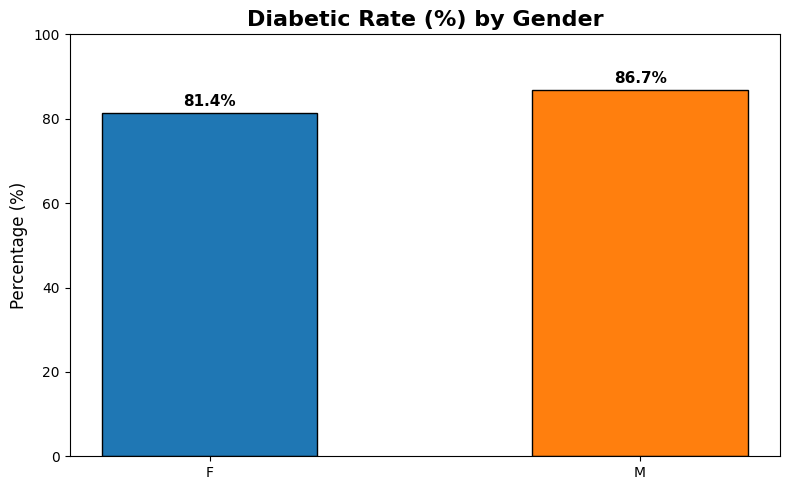


Diabetic rate by gender (%):
Gender
F    81.4
M    86.7


In [43]:
# Group by Gender and CLASS, use observed=True to avoid FutureWarning
gender_class = df.groupby(['Gender', 'CLASS'], observed=True).size().unstack(fill_value=0)

# Convert to percentages
gender_pct = gender_class.div(gender_class.sum(axis=1), axis=0) * 100

# Plot
fig, ax = plt.subplots(figsize=(8, 5))

# Strong contrasting colors for genders
colors = ['#1f77b4', '#ff7f0e']  # e.g., blue for male, orange for female

# Only diabetic rates
diabetic_rates = gender_pct['Y']
bars = ax.bar(gender_pct.index, diabetic_rates,
              color=colors,
              width=0.5, edgecolor='black')

# Titles and labels
ax.set_title('Diabetic Rate (%) by Gender', fontsize=16, fontweight='bold')
ax.set_ylabel('Percentage (%)', fontsize=12)
ax.set_ylim(0, 100)

# Add values on top of bars
for bar, val in zip(bars, diabetic_rates):
    ax.text(bar.get_x() + bar.get_width()/2, val + 1,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

# Print percentages
print("\nDiabetic rate by gender (%):")
print(gender_pct['Y'].round(1).to_string())